# 3. Custom pupil + Zernike DM (VAMPIRES)

Wraps an external pupil-generation function (`miles_pupil`) via the `external_pupil` aperture, and drives a Zernike-mode deformable mirror. The fixture config reproduces the 2023-10 VAMPIRES base setup against the captured digest.

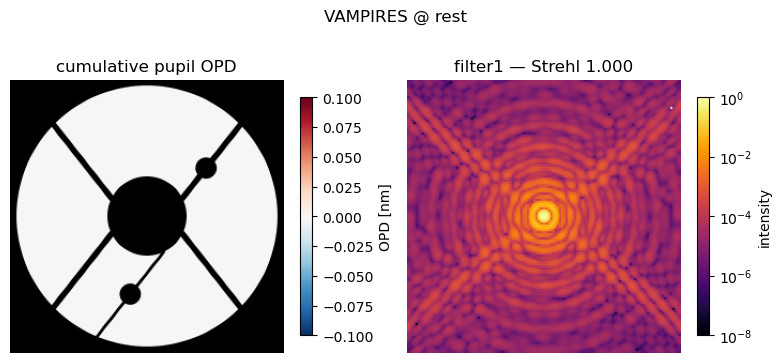

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from telescope_sim import TelescopeSim
from telescope_sim.helpers.diagnostics import plot_opd_and_psfs

sim = TelescopeSim.from_yaml("fixtures/configs/09_vampires_base.yaml")
out = sim.sample(meas_strehl=True, meas_pupil_opd=True)

plot_opd_and_psfs(sim, out, suptitle='VAMPIRES @ rest')
plt.show()


Push a few Zernike modes and see the focal plane respond — the OPD panel makes the mode shape directly visible alongside the resulting PSF.

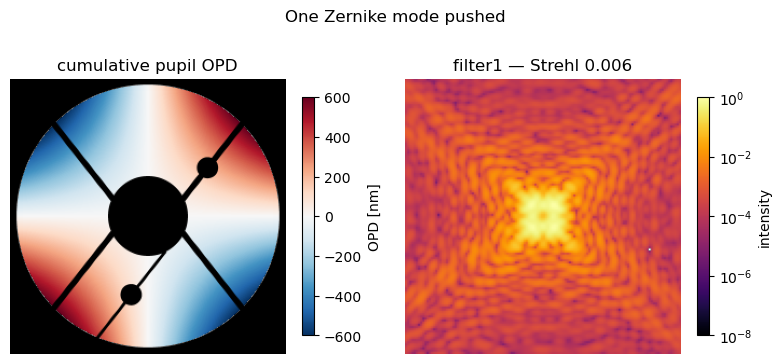

In [2]:
amps = np.zeros(10)
amps[3] = 0.3   # one of the low-order modes
out = sim.sample(
    actuations={"zernike_dm": amps},
    meas_strehl=True, meas_pupil_opd=True,
)
plot_opd_and_psfs(sim, out, suptitle='One Zernike mode pushed')
plt.show()


## Atmosphere as a per-sample input

Atmospheres are **not** correctors — they flow into the pipeline as the `atmos=` kwarg on `sample()`. Any wf→wf callable works; HCIPy's
`InfiniteAtmosphericLayer` is the typical case. The caller owns time evolution (call `atmos.evolve_until(t)` between samples); `telescope-sim` stays stateless.

If the atmosphere also exposes `phase_for(lam)`, its OPD seeds the cumulative-OPD stream that downstream **fit-role** correctors consume — so a DM declared with `wavefront_role="fit"` and `fit_source="cumulative_phase_pre_self"` will auto-fit (and cancel) the atmosphere. No bespoke atmosphere-corrector required.

atmos exposes phase_for?  True
Strehl no atmos:  1.000
Strehl atmos on: 0.416
atmos OPD RMS:   155.2 nm


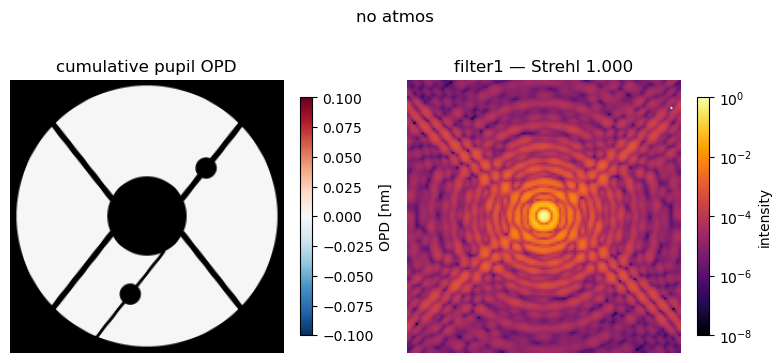

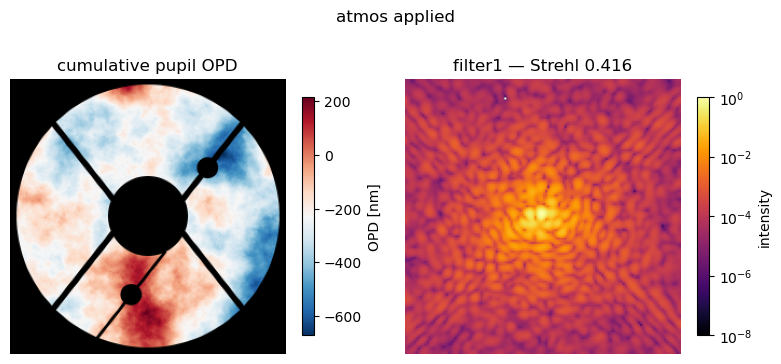

In [3]:
import hcipy

# Single-layer Kolmogorov turbulence on the existing pupil grid. The
# Fried parameter r0 is set generously (1.5m at 760nm — well above the
# typical seeing limit) so the 10-mode Zernike basis can do most of
# the work; the point of this demo is the wiring, not state-of-the-art
# AO performance.
pupil_grid = sim.aperture.field.grid
wavelength = 0.760e-6
fried = 1.5
Cn2 = hcipy.Cn_squared_from_fried_parameter(fried, wavelength)
atmos = hcipy.InfiniteAtmosphericLayer(
    pupil_grid, Cn2, L0=20.0, velocity=10.0, height=0.0,
)
atmos.evolve_until(0.0)
print('atmos exposes phase_for? ', hasattr(atmos, 'phase_for'))

out_clean = sim.sample(meas_strehl=True, meas_pupil_opd=True)
out_atmos = sim.sample(atmos=atmos, meas_strehl=True, meas_pupil_opd=True)
print(f'Strehl no atmos:  {out_clean["strehls"]["filter1"]:.3f}')
print(f'Strehl atmos on: {out_atmos["strehls"]["filter1"]:.3f}')
print(f'atmos OPD RMS:   {1e9 * out_atmos["pupil_opd"].std():.1f} nm')

plot_opd_and_psfs(sim, out_clean, suptitle='no atmos')
plot_opd_and_psfs(sim, out_atmos, suptitle='atmos applied')
plt.show()


Now build a sim variant with the Zernike DM in **fit-role**, fitting `cumulative_phase_pre_self`. With the same atmosphere injected, the DM auto-cancels it — no actuator commands required from the caller. `target_strategy="actuators_plus_residual_fit"` makes `out["actuations"]` report the actuator values needed; for ML training, this is the natural supervision signal.

Strehl with fit-role DM: 0.782
fit values shape: (30,)
residual OPD RMS: 111.6 nm


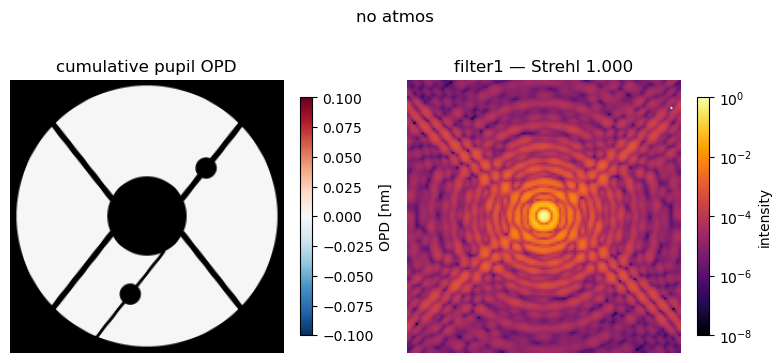

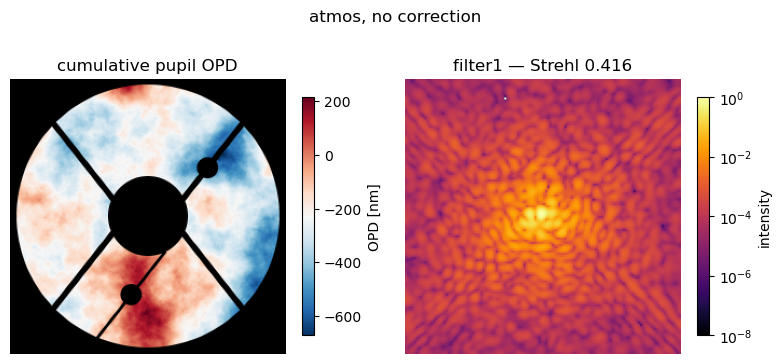

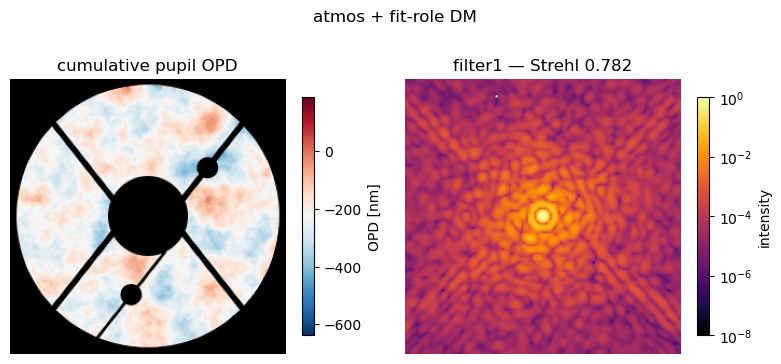

In [4]:
import yaml
from pathlib import Path
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build

fit_cfg = yaml.safe_load(
    Path('fixtures/configs/09_vampires_base.yaml').read_text()
)
# Flip the existing zernike_dm into a fit-role corrector that fits
# whatever cumulative OPD it sees upstream (here: just atmos).
fit_cfg['correctors']['zernike_dm'].update({
    'n_modes': 30,                # more horsepower than the 10-mode default
    'starting_mode': 2,
    'wavefront_role': 'fit',
    'target_strategy': 'actuators_plus_residual_fit',
    'fit_source': 'cumulative_phase_pre_self',
    'target': True,
})
fit_sim = build(SimConfig.model_validate(fit_cfg))

atmos.evolve_until(0.0)  # reset the layer to the same frozen phase
out_corrected = fit_sim.sample(
    atmos=atmos, meas_strehl=True, meas_pupil_opd=True,
)
print(f"Strehl with fit-role DM: {out_corrected['strehls']['filter1']:.3f}")
print('fit values shape:', out_corrected['actuations']['zernike_dm'].shape)
print(f'residual OPD RMS: {1e9 * out_corrected["pupil_opd"].std():.1f} nm')

# Three side-by-side OPD+PSF panels — clean / atmos uncorrected /
# atmos corrected. The OPD panels make the recovery story explicit:
# atmospheric phase in panel 2 nearly vanishes in panel 3.
plot_opd_and_psfs(sim, out_clean, suptitle='no atmos')
plot_opd_and_psfs(sim, out_atmos, suptitle='atmos, no correction')
plot_opd_and_psfs(fit_sim, out_corrected, suptitle='atmos + fit-role DM')
plt.show()
